# Amazon Fine Food Review Score Prediction

This notebook builds a complete machine learning pipeline for predicting Amazon review scores from review text.

The task is a supervised multi-class classification problem where the input is the combined review summary and full review text, and the output is a rating score from 1 to 5.

Models used:
- Logistic Regression
- Linear SVM
- BERT

Evaluation metrics:
- Accuracy
- Macro F1 Score
- Weighted F1 Score
- Confusion Matrix
***

## 1. Imports

In [1]:
!pip install langdetect
!pip install gensim

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# Download required NLTK resources
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from langdetect import detect, LangDetectException, DetectorFactory
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.base import BaseEstimator, TransformerMixin
from gensim.models import Word2Vec

warnings.filterwarnings("ignore")

# Global random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Make language detection deterministic
DetectorFactory.seed = RANDOM_STATE

# Cross-validation strategy used inside GridSearchCV
cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

##2. Load Raw Dataset

In [2]:
df = pd.read_csv("Reviews.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## 3. Data Cleaning and Preprocessing

This section prepares the raw dataset for modeling. The preprocessing steps include:

- Handling missing values in `Summary` and `Text`
- Removing exact duplicate rows
- Combining `Summary` and `Text` into one review field
- Removing HTML tags, punctuation, special characters, and extra spaces
- Lowercasing and text normalization
- Removing non-English reviews using language detection
- Tokenization, stopword removal, and lemmatization
- Filtering reviews from 2010 onward

Two text versions are kept:
- `review_text_clean`: cleaned text used for TF-IDF and BERT
- `review_text_processed`: tokenized, stopword-removed, and lemmatized text used for Word2Vec

In [3]:
def clean_text(text):
    """
    Clean review text by removing HTML tags, punctuation,
    special characters, converting to lowercase, and removing extra spaces.
    """
    text = BeautifulSoup(str(text), "html.parser").get_text()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def is_english_review(text):
    """
    Detect whether a review is written in English.
    If language detection fails, the review is removed.
    """
    try:
        return detect(str(text)) == "en"
    except LangDetectException:
        return False


def tokenize_remove_stopwords_lemmatize(text):
    """
    Tokenize cleaned review text, remove English stopwords,
    and lemmatize tokens.
    """
    tokens = word_tokenize(str(text))

    # Keep alphabetic tokens only
    tokens = [token for token in tokens if token.isalpha()]

    # Remove stopwords
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize tokens
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return tokens


def preprocess_reviews(data):
    """
    Prepare the Amazon Fine Food Reviews dataset.

    Steps:
    - Handle missing Summary/Text values
    - Remove exact duplicate rows
    - Combine Summary and Text
    - Remove HTML tags
    - Convert text to lowercase
    - Remove punctuation and special characters
    - Remove non-English reviews
    - Tokenize text
    - Remove stopwords
    - Lemmatize tokens
    - Convert Time to Year
    - Keep reviews from 2010 onward
    """
    data = data.copy()

    print("Original dataset size:", len(data))

    # Handle missing text fields
    data["Summary"] = data["Summary"].fillna("")
    data["Text"] = data["Text"].fillna("")

    # Remove exact duplicate rows only
    data = data.drop_duplicates()
    print("After exact duplicate row removal:", len(data))

    # Combine Summary and Text into one review field
    data["review_text_original"] = data["Summary"] + " " + data["Text"]

    # Basic text cleaning
    data["review_text_clean"] = data["review_text_original"].apply(clean_text)

    # Remove empty cleaned reviews
    data = data[data["review_text_clean"].str.len() > 0]

    # Remove non-English reviews
    data = data[data["review_text_clean"].apply(is_english_review)]
    print("After non-English review removal:", len(data))

    # Tokenization, stopword removal, and lemmatization
    data["tokens"] = data["review_text_clean"].apply(tokenize_remove_stopwords_lemmatize)

    # Create a processed text version from the tokens
    # This is useful for Word2Vec and EDA.
    data["review_text_processed"] = data["tokens"].apply(lambda tokens: " ".join(tokens))

    # Remove rows that became empty after stopword removal
    data = data[data["review_text_processed"].str.len() > 0]

    # Convert timestamp to year
    data["Time"] = pd.to_datetime(data["Time"], unit="s")
    data["Year"] = data["Time"].dt.year

    # Keep reviews from 2010 onward
    data = data[data["Year"] >= 2010]
    print("After filtering reviews from 2010 onward:", len(data))

    # Ensure score is integer
    data["Score"] = data["Score"].astype(int)

    print("Final cleaned dataset size:", len(data))

    return data[
        [
            "Score",
            "review_text_clean",
            "review_text_processed",
            "tokens",
            "Year"
        ]
    ]

In [4]:
clean_df = preprocess_reviews(df)

print(clean_df.shape)
clean_df.head()

Original dataset size: 568454
After exact duplicate row removal: 568454
After non-English review removal: 568187
After filtering reviews from 2010 onward: 447651
Final cleaned dataset size: 447651
(447651, 5)


,Score,review_text_clean,review_text_processed,tokens,Year
0,5,good quality dog food i have bought several of...,good quality dog food bought several vitality ...,"[good, quality, dog, food, bought, several, vi...",2011
1,1,not as advertised product arrived labeled as j...,advertised product arrived labeled jumbo salte...,"[advertised, product, arrived, labeled, jumbo,...",2012
3,2,cough medicine if you are looking for the secr...,cough medicine looking secret ingredient robit...,"[cough, medicine, looking, secret, ingredient,...",2011
4,5,great taffy great taffy at a great price there...,great taffy great taffy great price wide assor...,"[great, taffy, great, taffy, great, price, wid...",2012
5,4,nice taffy i got a wild hair for taffy and ord...,nice taffy got wild hair taffy ordered five po...,"[nice, taffy, got, wild, hair, taffy, ordered,...",2012


## 4. Exploratory Data Analysis

This section summarizes the cleaned dataset using visualizations. The class distribution plot shows the imbalance in review scores, while the text-length distribution helps understand the variation in review length.


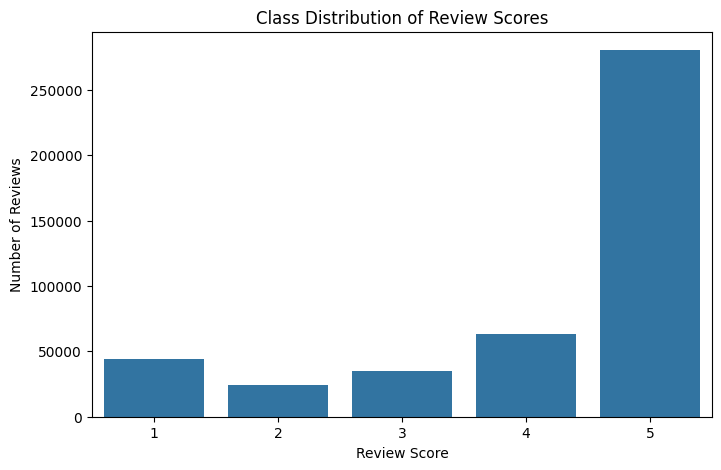

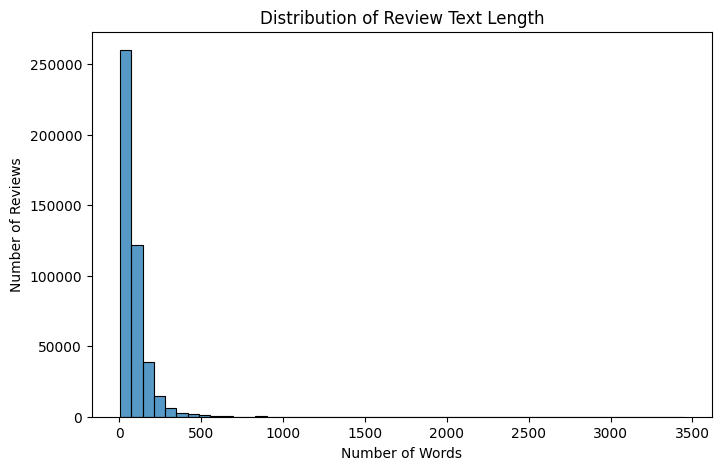

,review_text_clean,Score,Year
502692,starlights licorice hard cand this is the best...,5,2012
115218,interesting texture and super yummy my month o...,5,2012
251045,lots of fun we really enjoyed this experience ...,5,2012
317273,disappointed items were poorly packed and arri...,2,2012
294325,love this stuff on my rd order i totally love ...,5,2011


In [5]:
class_counts = clean_df["Score"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.show()

class_counts

clean_df["text_length"] = clean_df["review_text_clean"].str.split().apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(clean_df["text_length"], bins=50)
plt.title("Distribution of Review Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()
clean_df.sample(5, random_state=RANDOM_STATE)[["review_text_clean", "Score", "Year"]]

## 5. Train / Validation / Test Split

The dataset is split before feature extraction to prevent data leakage.
All text vectorizers and models are fitted only on the training data.
The validation set is used for hyperparameter tuning and model selection, while the test set is kept untouched until the final evaluation.

In [6]:
train_df, temp_df = train_test_split(
    clean_df,
    test_size=0.30,
    stratify=clean_df["Score"],
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=2/3,
    stratify=temp_df["Score"],
    random_state=RANDOM_STATE
)

print("Training size:", len(train_df))
print("Validation size:", len(val_df))
print("Testing size:", len(test_df))

Training size: 313355
Validation size: 44765
Testing size: 89531


In [7]:
print("Training distribution before balancing:")
print(train_df["Score"].value_counts().sort_index())

print("\nValidation distribution:")
print(val_df["Score"].value_counts().sort_index())

print("\nTest distribution:")
print(test_df["Score"].value_counts().sort_index())

Training distribution before balancing:
Score
1     30936
2     17229
3     24401
4     44381
5    196408
Name: count, dtype: int64

Validation distribution:
Score
1     4420
2     2461
3     3486
4     6340
5    28058
Name: count, dtype: int64

Test distribution:
Score
1     8839
2     4923
3     6972
4    12680
5    56117
Name: count, dtype: int64


,Train,Validation,Test
Score,,,
1,30936,4420,8839
2,17229,2461,4923
3,24401,3486,6972
4,44381,6340,12680
5,196408,28058,56117


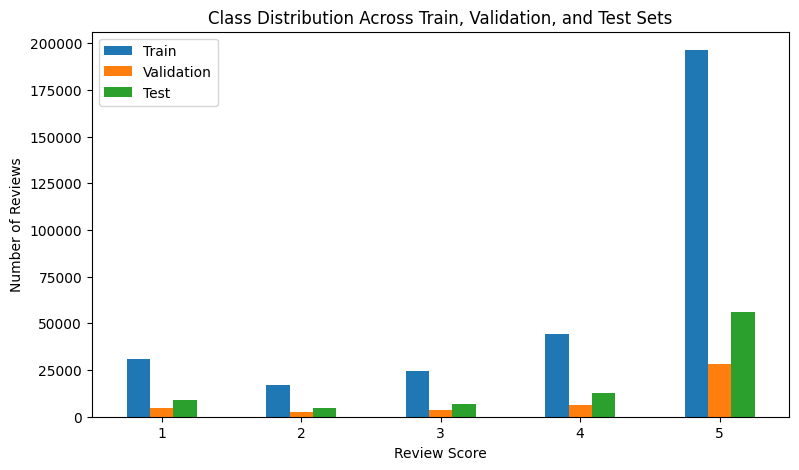

In [8]:
split_distribution = pd.DataFrame({
    "Train": train_df["Score"].value_counts().sort_index(),
    "Validation": val_df["Score"].value_counts().sort_index(),
    "Test": test_df["Score"].value_counts().sort_index()
})

display(split_distribution)

split_distribution.plot(kind="bar", figsize=(9, 5))
plt.title("Class Distribution Across Train, Validation, and Test Sets")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

**Training-set balancing section**

In [9]:
def balance_training_set(train_data, label_col="Score", target_per_class=15000, random_state=42):
    """
    Balance only the training set by randomly sampling the same number
    of examples from each class.

    This function does not modify validation or test sets.
    """
    class_counts = train_data[label_col].value_counts().sort_index()

    print("Class distribution before balancing:")
    print(class_counts)

    if class_counts.min() < target_per_class:
        raise ValueError(
            f"At least one class has fewer than {target_per_class} examples. "
            f"Smallest class has {class_counts.min()} examples. "
            "Check preprocessing or reduce target_per_class."
        )

    balanced_train = (
        train_data
        .groupby(label_col, group_keys=False)
        .apply(lambda x: x.sample(n=target_per_class, replace=False, random_state=random_state))
        .sample(frac=1, random_state=random_state)
        .reset_index(drop=True)
    )

    print("\nClass distribution after balancing:")
    print(balanced_train[label_col].value_counts().sort_index())

    return balanced_train

In [10]:
train_balanced_df = balance_training_set(
    train_df,
    label_col="Score",
    target_per_class=15000,
    random_state=RANDOM_STATE
)

Class distribution before balancing:
Score
1     30936
2     17229
3     24401
4     44381
5    196408
Name: count, dtype: int64

Class distribution after balancing:
Score
1    15000
2    15000
3    15000
4    15000
5    15000
Name: count, dtype: int64


**Update the variables used for training**

In [11]:
# Text used for TF-IDF and BERT
X_train_balanced = train_balanced_df["review_text_clean"]
X_val = val_df["review_text_clean"]
X_test = test_df["review_text_clean"]

# Text used for Word2Vec
X_train_w2v_balanced = train_balanced_df["review_text_processed"]
X_val_w2v = val_df["review_text_processed"]
X_test_w2v = test_df["review_text_processed"]

# Labels
y_train_balanced = train_balanced_df["Score"]
y_val = val_df["Score"]
y_test = test_df["Score"]

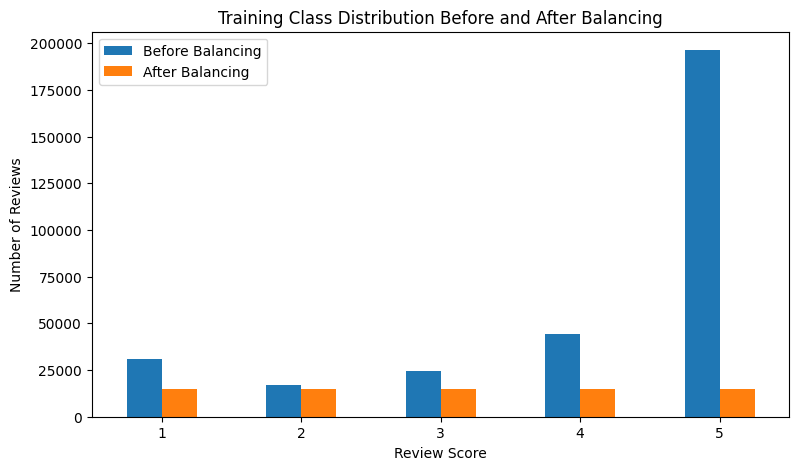

In [12]:
before_balance = train_df["Score"].value_counts().sort_index()
after_balance = train_balanced_df["Score"].value_counts().sort_index()

balance_comparison = pd.DataFrame({
    "Before Balancing": before_balance,
    "After Balancing": after_balance
})

balance_comparison.plot(kind="bar", figsize=(9, 5))
plt.title("Training Class Distribution Before and After Balancing")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## 6. Evaluation Function

In [13]:
def plot_confusion_matrix(y_true, y_pred, title):
    """
    Plot a confusion matrix for review score prediction.
    Class labels are shown as review scores from 1 to 5.
    """
    cm = confusion_matrix(y_true, y_pred, labels=[1, 2, 3, 4, 5])

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[1, 2, 3, 4, 5],
        yticklabels=[1, 2, 3, 4, 5]
    )
    plt.title(f"Confusion Matrix - {title}")
    plt.xlabel("Predicted Score")
    plt.ylabel("Actual Score")
    plt.show()


def evaluate_model(model, X_data, y_true, model_name, plot_cm=False):
    """
    Evaluate a trained traditional ML model using accuracy, macro F1,
    weighted F1, and optionally a confusion matrix.
    """
    y_pred = model.predict(X_data)

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred , zero_division=0))

    if plot_cm:
        plot_confusion_matrix(y_true, y_pred, model_name)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    }


# Traditional Models

For traditional models, feature extraction is performed only after the train/validation/test split.

TF-IDF and Word2Vec are placed inside the modeling pipelines so that they are fitted only on the training folds during cross-validation.This prevents data leakage and produces a fairer estimate of generalization performance.


##7. Logistic Regression + TF-IDF

In [14]:
tfidf_lr_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

tfidf_lr_params = {
    "tfidf__max_features": [10000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [3, 5],
    "classifier__C": [0.1, 1, 10]
}

grid_tfidf_lr = GridSearchCV(
    estimator=tfidf_lr_pipeline,
    param_grid=tfidf_lr_params,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2
)

grid_tfidf_lr.fit(X_train_balanced, y_train_balanced)
print("Best parameters:")
print(grid_tfidf_lr.best_params_)

print("Best CV Macro F1:")
print(grid_tfidf_lr.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters:
{'classifier__C': 10, 'tfidf__max_features': 20000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best CV Macro F1:
0.6286561125483344


In [15]:
tfidf_lr_val_results = evaluate_model(
    grid_tfidf_lr.best_estimator_,
    X_val,
    y_val,
    "Logistic Regression + TF-IDF"
)

Logistic Regression + TF-IDF
Accuracy: 0.6803
Macro F1: 0.5911
Weighted F1: 0.7041

Classification Report:
              precision    recall  f1-score   support

           1       0.70      0.73      0.71      4420
           2       0.41      0.61      0.49      2461
           3       0.44      0.60      0.51      3486
           4       0.36      0.57      0.44      6340
           5       0.92      0.71      0.80     28058

    accuracy                           0.68     44765
   macro avg       0.57      0.64      0.59     44765
weighted avg       0.76      0.68      0.70     44765



##8. Linear SVM + TF-IDF

In [16]:
tfidf_svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("classifier", LinearSVC(random_state=RANDOM_STATE))
])

tfidf_svm_params = {
    "tfidf__max_features": [10000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [3, 5],
    "classifier__C": [0.1, 1, 10]
}

grid_tfidf_svm = GridSearchCV(
    estimator=tfidf_svm_pipeline,
    param_grid=tfidf_svm_params,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2
)

grid_tfidf_svm.fit(X_train_balanced, y_train_balanced)
print("Best parameters:")
print(grid_tfidf_svm.best_params_)

print("Best CV Macro F1:")
print(grid_tfidf_svm.best_score_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters:
{'classifier__C': 1, 'tfidf__max_features': 20000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best CV Macro F1:
0.6189298563814021


In [17]:
tfidf_svm_val_results = evaluate_model(
    grid_tfidf_svm.best_estimator_,
    X_val,
    y_val,
    "Linear SVM + TF-IDF"
)

Linear SVM + TF-IDF
Accuracy: 0.688
Macro F1: 0.5862
Weighted F1: 0.7091

Classification Report:
              precision    recall  f1-score   support

           1       0.68      0.74      0.71      4420
           2       0.39      0.57      0.46      2461
           3       0.44      0.58      0.50      3486
           4       0.38      0.55      0.45      6340
           5       0.92      0.73      0.82     28058

    accuracy                           0.69     44765
   macro avg       0.56      0.64      0.59     44765
weighted avg       0.75      0.69      0.71     44765



***

#Word2Vec Experiments
##9. Word2Vec Vectorizer Class

In [18]:
class AverageWord2VecVectorizer(BaseEstimator, TransformerMixin):
    """
    Custom sklearn-compatible Word2Vec vectorizer.
    Trains Word2Vec on training text only and represents
    each review as the average of its word vectors.
    """

    def __init__(self, vector_size=100, window=5, min_count=5, workers=4, random_state=42):
        self.vector_size = vector_size
        self.window = window
        self.min_count = min_count
        self.workers = workers
        self.random_state = random_state
        self.model = None

    def tokenize(self, texts):
        return [str(text).split() for text in texts]

    def fit(self, X, y=None):
        tokenized_texts = self.tokenize(X)

        self.model = Word2Vec(
            sentences=tokenized_texts,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            workers=self.workers,
            seed=self.random_state
        )

        return self

    def transform(self, X):
        tokenized_texts = self.tokenize(X)
        vectors = []

        for tokens in tokenized_texts:
            word_vectors = [
                self.model.wv[word]
                for word in tokens
                if word in self.model.wv
            ]

            if len(word_vectors) == 0:
                vectors.append(np.zeros(self.vector_size))
            else:
                vectors.append(np.mean(word_vectors, axis=0))

        return np.array(vectors)

##10.Logistic Regression + Word2Vec

In [19]:
w2v_lr_pipeline = Pipeline([
    ("w2v", AverageWord2VecVectorizer(random_state=RANDOM_STATE)),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

w2v_lr_params = {
    "w2v__vector_size": [100, 200],
    "w2v__window": [5],
    "w2v__min_count": [3, 5],
    "classifier__C": [0.1, 1, 10]
}

grid_w2v_lr = GridSearchCV(
    estimator=w2v_lr_pipeline,
    param_grid=w2v_lr_params,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=1,
    verbose=2
)

grid_w2v_lr.fit(X_train_w2v_balanced, y_train_balanced)
print("Best parameters:")
print(grid_w2v_lr.best_params_)

print("Best CV Macro F1:", grid_w2v_lr.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=100, w2v__window=5; total time=   7.9s
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=100, w2v__window=5; total time=   7.7s
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=100, w2v__window=5; total time=   8.9s
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=200, w2v__window=5; total time=  14.3s
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=200, w2v__window=5; total time=  13.5s
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=200, w2v__window=5; total time=  14.6s
[CV] END classifier__C=0.1, w2v__min_count=5, w2v__vector_size=100, w2v__window=5; total time=   7.4s
[CV] END classifier__C=0.1, w2v__min_count=5, w2v__vector_size=100, w2v__window=5; total time=   8.1s
[CV] END classifier__C=0.1, w2v__min_count=5, w2v__vector_size=100, w2v__window=5; total time=   8.6s
[CV] END classifier__

In [20]:
w2v_lr_val_results = evaluate_model(
    grid_w2v_lr.best_estimator_,
    X_val_w2v,
    y_val,
    "Logistic Regression + Word2Vec"
)

Logistic Regression + Word2Vec
Accuracy: 0.5938
Macro F1: 0.4621
Weighted F1: 0.6261

Classification Report:
              precision    recall  f1-score   support

           1       0.54      0.67      0.60      4420
           2       0.23      0.39      0.29      2461
           3       0.26      0.39      0.31      3486
           4       0.29      0.42      0.35      6340
           5       0.89      0.66      0.76     28058

    accuracy                           0.59     44765
   macro avg       0.44      0.51      0.46     44765
weighted avg       0.69      0.59      0.63     44765



##11.Linear SVM + Word2Vec

In [21]:
w2v_svm_pipeline = Pipeline([
    ("w2v", AverageWord2VecVectorizer(random_state=RANDOM_STATE)),
    ("scaler", StandardScaler()),
    ("classifier", LinearSVC(random_state=RANDOM_STATE))
])

w2v_svm_params = {
    "w2v__vector_size": [100, 200],
    "w2v__window": [5],
    "w2v__min_count": [3, 5],
    "classifier__C": [0.1, 1, 10]
}

grid_w2v_svm = GridSearchCV(
    estimator=w2v_svm_pipeline,
    param_grid=w2v_svm_params,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=1,
    verbose=2
)

grid_w2v_svm.fit(X_train_w2v_balanced, y_train_balanced)
print("Best parameters:")
print(grid_w2v_svm.best_params_)

print("Best CV Macro F1:", grid_w2v_svm.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=100, w2v__window=5; total time=  14.1s
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=100, w2v__window=5; total time=  15.7s
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=100, w2v__window=5; total time=  13.4s
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=200, w2v__window=5; total time= 1.5min
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=200, w2v__window=5; total time= 1.6min
[CV] END classifier__C=0.1, w2v__min_count=3, w2v__vector_size=200, w2v__window=5; total time= 1.5min
[CV] END classifier__C=0.1, w2v__min_count=5, w2v__vector_size=100, w2v__window=5; total time=  15.2s
[CV] END classifier__C=0.1, w2v__min_count=5, w2v__vector_size=100, w2v__window=5; total time=  14.3s
[CV] END classifier__C=0.1, w2v__min_count=5, w2v__vector_size=100, w2v__window=5; total time=  13.9s
[CV] END classifier__

In [22]:
w2v_svm_val_results = evaluate_model(
    grid_w2v_svm.best_estimator_,
    X_val,
    y_val,
    "Linear SVM + Word2Vec"
)

Linear SVM + Word2Vec
Accuracy: 0.6308
Macro F1: 0.4632
Weighted F1: 0.6476

Classification Report:
              precision    recall  f1-score   support

           1       0.51      0.72      0.59      4420
           2       0.23      0.35      0.28      2461
           3       0.29      0.32      0.30      3486
           4       0.33      0.36      0.34      6340
           5       0.87      0.74      0.80     28058

    accuracy                           0.63     44765
   macro avg       0.44      0.50      0.46     44765
weighted avg       0.68      0.63      0.65     44765



## 12. Traditional Model Validation Results Summary

The following table summarizes validation performance for the traditional models only. BERT is added later to the full validation comparison after fine-tuning.


In [23]:
traditional_validation_results = pd.DataFrame([
    tfidf_lr_val_results,
    tfidf_svm_val_results,
    w2v_lr_val_results,
    w2v_svm_val_results
])

traditional_validation_results

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression + TF-IDF,0.680308,0.591058,0.704083
1,Linear SVM + TF-IDF,0.687971,0.586190,0.709140
2,Logistic Regression + Word2Vec,0.593767,0.462146,0.626111
3,Linear SVM + Word2Vec,0.630761,0.463204,0.647567


#BERT Model

## 13. BERT Setup

BERT uses raw cleaned review text rather than TF-IDF or Word2Vec features. The tokenizer converts each review into token IDs that the pre-trained BERT model can process. SMOTE is not used with BERT because SMOTE operates on numerical feature vectors, not raw text sequences.


In [24]:
!pip install -q transformers accelerate torch

In [25]:
import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)

##13. Prepare BERT Labels

In [26]:
label_map = {1: 0, 2: 1, 3: 2, 4: 3, 5: 4}
reverse_label_map = {0: "1", 1: "2", 2: "3", 3: "4", 4: "5"}

##14. PyTorch Dataset for BERT

In [27]:
class ReviewDataset(Dataset):
    """
    PyTorch Dataset for BERT fine-tuning.
    Converts raw text into tokenized model inputs.
    """

    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])
        label = int(self.labels[index])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding=False,
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)

        return item

##15. Tokenizer and Model

In [28]:
MODEL_NAME = "bert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

y_train_bert = y_train_balanced.map(label_map)
y_val_bert = y_val.map(label_map)
y_test_bert = y_test.map(label_map)

bert_train_dataset = ReviewDataset(
    X_train_balanced,
    y_train_bert,
    tokenizer
)

bert_val_dataset = ReviewDataset(
    X_val,
    y_val_bert,
    tokenizer
)

bert_test_dataset = ReviewDataset(
    X_test,
    y_test_bert,
    tokenizer
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=5,
    id2label=reverse_label_map,
    label2id={"1": 0, "2": 1, "3": 2, "4": 3, "5": 4}
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##16. BERT Metrics

In [29]:
def compute_bert_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "macro_f1": f1_score(labels, predictions, average="macro"),
        "weighted_f1": f1_score(labels, predictions, average="weighted")
    }

##17. Train BERT

In [30]:
training_args = TrainingArguments(
    output_dir="./bert_amazon_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    save_total_limit=1,
    fp16=torch.cuda.is_available()
)

bert_trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=bert_train_dataset,
    eval_dataset=bert_val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_bert_metrics
)

bert_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.925012,0.678111,0.732916,0.628863,0.751169
2,0.708281,0.632488,0.758986,0.660574,0.770913
3,0.565781,0.706298,0.747571,0.665505,0.765153


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=28125, training_loss=0.7330244965277778, metrics={'train_runtime': 667.1973, 'train_samples_per_second': 337.232, 'train_steps_per_second': 42.154, 'total_flos': 2.4161526450543696e+16, 'train_loss': 0.7330244965277778, 'epoch': 3.0})

## 18. BERT Learning Curves

The training logs are used to visualize BERT's learning behavior across epochs. These curves help assess whether the model is improving and whether there are signs of overfitting.


In [31]:
bert_logs = pd.DataFrame(bert_trainer.state.log_history)
bert_logs

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_f1,eval_weighted_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.925012,18.439194,6.667022e-06,1.0,9375,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,1.0,9375,0.678111,0.732916,0.628863,0.751169,35.6691,1255.009,156.887,NaN,NaN,NaN,NaN,NaN
2,0.708281,29.247187,3.333689e-06,2.0,18750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,2.0,18750,0.632488,0.758986,0.660574,0.770913,35.7489,1252.206,156.536,NaN,NaN,NaN,NaN,NaN
4,0.565781,32.494366,3.555556e-10,3.0,28125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,3.0,28125,0.706298,0.747571,0.665505,0.765153,36.0200,1242.781,155.358,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,3.0,28125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,667.1973,337.232,42.154,2.416153e+16,0.733024


**Training loss curve:**

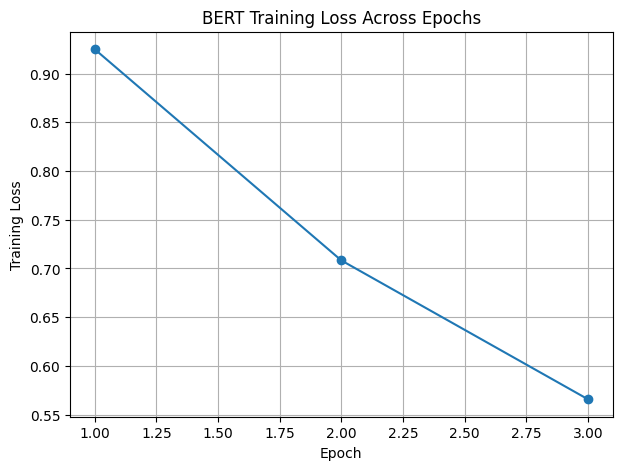

In [32]:
train_logs = bert_logs.dropna(subset=["loss"])

plt.figure(figsize=(7, 5))
plt.plot(train_logs["epoch"], train_logs["loss"], marker="o")
plt.title("BERT Training Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.grid(True)
plt.show()

##18. BERT Validation Evaluation

In [33]:
bert_val_results_raw = bert_trainer.evaluate(bert_val_dataset)
bert_val_results_raw

{'eval_loss': 0.7062979340553284,
 'eval_accuracy': 0.7475706467105998,
 'eval_macro_f1': 0.6655045101830339,
 'eval_weighted_f1': 0.7651532511798547,
 'eval_runtime': 35.6923,
 'eval_samples_per_second': 1254.19,
 'eval_steps_per_second': 156.784,
 'epoch': 3.0}

In [34]:
bert_val_results = {
    "Model": "BERT",
    "Accuracy": bert_val_results_raw["eval_accuracy"],
    "Macro F1": bert_val_results_raw["eval_macro_f1"],
    "Weighted F1": bert_val_results_raw["eval_weighted_f1"]
}

bert_val_results

{'Model': 'BERT',
 'Accuracy': 0.7475706467105998,
 'Macro F1': 0.6655045101830339,
 'Weighted F1': 0.7651532511798547}

**Validation loss curve:**

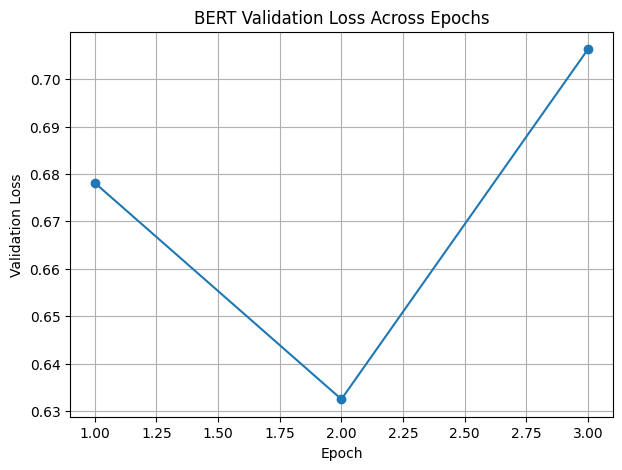

In [35]:
eval_logs = bert_logs.dropna(subset=["eval_loss"])

plt.figure(figsize=(7, 5))
plt.plot(eval_logs["epoch"], eval_logs["eval_loss"], marker="o")
plt.title("BERT Validation Loss Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.grid(True)
plt.show()

**validation Macro F1 curve**

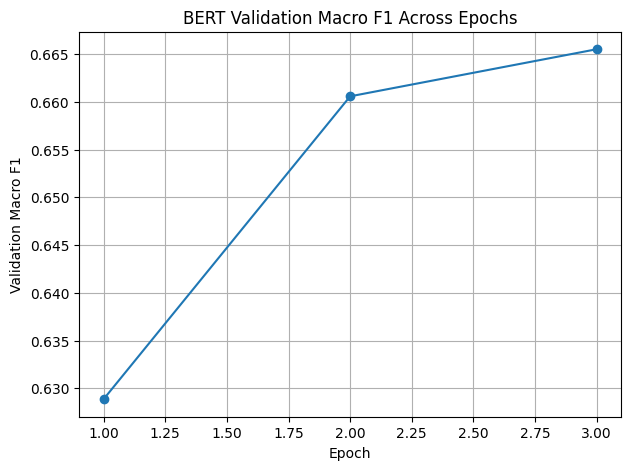

In [36]:
eval_metric_logs = bert_logs.dropna(subset=["eval_macro_f1"])

plt.figure(figsize=(7, 5))
plt.plot(eval_metric_logs["epoch"], eval_metric_logs["eval_macro_f1"], marker="o")
plt.title("BERT Validation Macro F1 Across Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.grid(True)
plt.show()

## 20. Validation Comparison Visuals

All models are compared using validation metrics. The best model is selected based on validation Macro F1 because Macro F1 treats all classes equally, which is important for imbalanced multi-class classification.


In [37]:
candidate_models = [
    {
        "name": "Logistic Regression + TF-IDF",
        "model_type": "traditional",
        "input_type": "clean_text",
        "model": grid_tfidf_lr.best_estimator_,
        "validation_results": tfidf_lr_val_results
    },
    {
        "name": "Linear SVM + TF-IDF",
        "model_type": "traditional",
        "input_type": "clean_text",
        "model": grid_tfidf_svm.best_estimator_,
        "validation_results": tfidf_svm_val_results
    },
    {
        "name": "Logistic Regression + Word2Vec",
        "model_type": "traditional",
        "input_type": "processed_text",
        "model": grid_w2v_lr.best_estimator_,
        "validation_results": w2v_lr_val_results
    },
    {
        "name": "Linear SVM + Word2Vec",
        "model_type": "traditional",
        "input_type": "processed_text",
        "model": grid_w2v_svm.best_estimator_,
        "validation_results": w2v_svm_val_results
    },
    {
        "name": "BERT",
        "model_type": "bert",
        "input_type": "bert",
        "model": bert_trainer,
        "validation_results": bert_val_results
    }
]

In [38]:
validation_results_df = pd.DataFrame([
    {
        "Model": item["name"],
        "Accuracy": item["validation_results"]["Accuracy"],
        "Macro F1": item["validation_results"]["Macro F1"],
        "Weighted F1": item["validation_results"]["Weighted F1"]
    }
    for item in candidate_models
])

validation_results_df = validation_results_df.sort_values("Macro F1", ascending=False)
validation_results_df

,Model,Accuracy,Macro F1,Weighted F1
4,BERT,0.747571,0.665505,0.765153
0,Logistic Regression + TF-IDF,0.680308,0.591058,0.704083
1,Linear SVM + TF-IDF,0.687971,0.586190,0.709140
3,Linear SVM + Word2Vec,0.630761,0.463204,0.647567
2,Logistic Regression + Word2Vec,0.593767,0.462146,0.626111


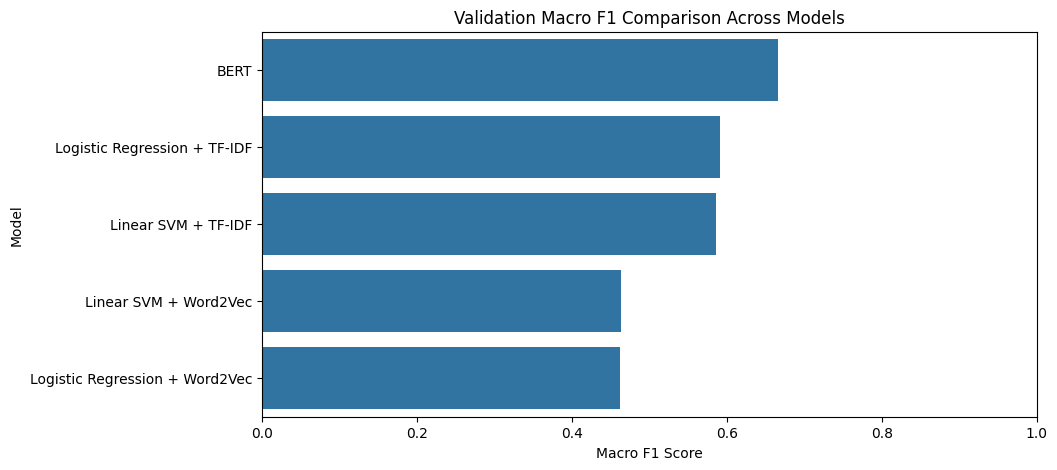

In [39]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=validation_results_df,
    x="Macro F1",
    y="Model"
)
plt.title("Validation Macro F1 Comparison Across Models")
plt.xlabel("Macro F1 Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

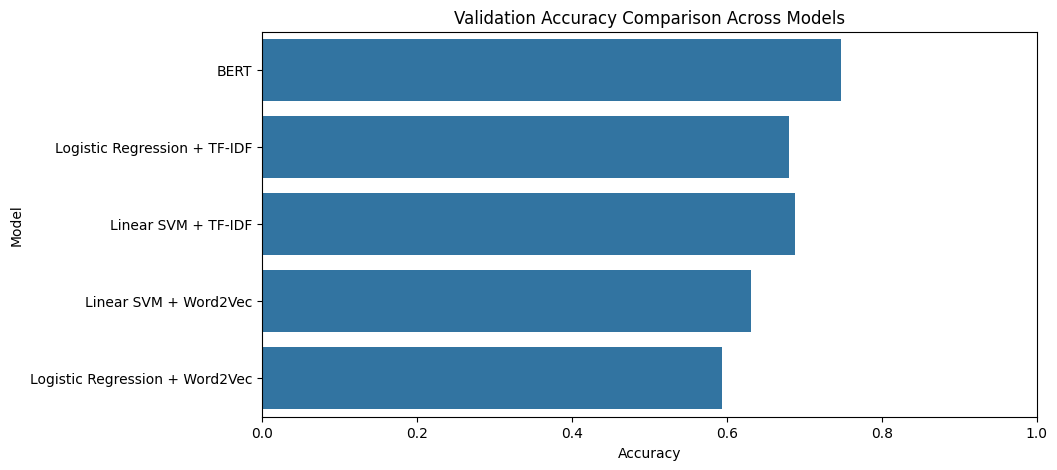

In [40]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=validation_results_df,
    x="Accuracy",
    y="Model"
)
plt.title("Validation Accuracy Comparison Across Models")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.show()

## 21. Select Best Model Using Validation Performance


In [41]:
best_candidate = max(
    candidate_models,
    key=lambda item: item["validation_results"]["Macro F1"]
)

print("Best model selected using validation Macro F1:")
print(best_candidate["name"])

Best model selected using validation Macro F1:
BERT


The best model is selected using validation Macro F1 score.
The test set is not used during model selection and remains untouched until the final evaluation.

# Final Test Evaluation


## 22. Test Set Used Once


The test set is evaluated only after all model selection and hyperparameter tuning are completed.
This ensures an unbiased final estimate of model generalization.

In [42]:
def evaluate_selected_model_on_test(best_candidate):
    """
    Evaluate only the selected best model on the test set.
    The test set is used once after model selection.
    """
    if best_candidate["model_type"] == "bert":
        trainer = best_candidate["model"]

        test_output = trainer.predict(bert_test_dataset)

        # Convert BERT labels from 0-4 back to original review scores 1-5
        y_true = test_output.label_ids + 1
        y_pred = np.argmax(test_output.predictions, axis=1) + 1

    else:
        model = best_candidate["model"]
        y_true = y_test

        if best_candidate["input_type"] == "processed_text":
            y_pred = model.predict(X_test_w2v)
        else:
            y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")

    print("=" * 70)
    print("Final Test Evaluation:", best_candidate["name"])
    print("=" * 70)
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))
    print("Weighted F1:", round(weighted_f1, 4))

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        labels=[1, 2, 3, 4, 5],
        zero_division=0
    ))

    plot_confusion_matrix(
        y_true,
        y_pred,
        f"Final Test Evaluation - {best_candidate['name']}"
    )

    return {
        "Model": best_candidate["name"],
        "Accuracy": accuracy,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1
    }

Final Test Evaluation: BERT
Accuracy: 0.7489
Macro F1: 0.6651
Weighted F1: 0.7665

Classification Report:
              precision    recall  f1-score   support

           1       0.82      0.76      0.79      8839
           2       0.49      0.66      0.56      4923
           3       0.55      0.65      0.60      6972
           4       0.43      0.66      0.52     12680
           5       0.94      0.79      0.86     56117

    accuracy                           0.75     89531
   macro avg       0.65      0.70      0.67     89531
weighted avg       0.80      0.75      0.77     89531



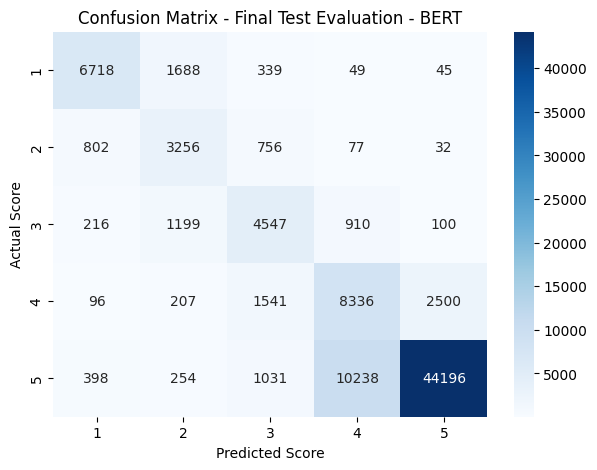

{'Model': 'BERT',
 'Accuracy': 0.7489361226837632,
 'Macro F1': 0.6651024941638838,
 'Weighted F1': 0.766480872791914}

In [43]:
final_test_result = evaluate_selected_model_on_test(best_candidate)
final_test_result

## 23. Final Selected Model Test Result


In [44]:
final_results_df = pd.DataFrame([final_test_result])
final_results_df

,Model,Accuracy,Macro F1,Weighted F1
0,BERT,0.748936,0.665102,0.766481


## 24. Save Results


In [45]:
final_results_df.to_csv("final_selected_model_test_result.csv", index=False)
validation_results_df.to_csv("validation_model_comparison.csv", index=False)